In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import plotly.express as px
import plotly.io as pio

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# 1. Llamar al conjunto de datos de nuestro proyecto
datos = pd.read_csv("../data/datos.csv")

df = pd.DataFrame(datos)

In [21]:
# Configurar el renderizador para que guarde los gráficos con el formato 
# compatible que GitHub e IDEs como VS Code pueden leer sin problemas
pio.renderers.default = "notebook_connected"

In [22]:
# Mostrar la información general de nuestro DataFrame
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Fecha         150 non-null    str    
 1   Año           150 non-null    int64  
 2   Trimestre     150 non-null    str    
 3   Apertura      150 non-null    float64
 4   Maximo        150 non-null    float64
 5   Minimo        150 non-null    float64
 6   Cierre        150 non-null    float64
 7   Volumen_M     150 non-null    float64
 8   Tendencia     150 non-null    str    
 9   Volumen_Alto  150 non-null    bool   
 10  Ganancia_Dia  150 non-null    bool   
dtypes: bool(2), float64(5), int64(1), str(3)
memory usage: 13.8 KB
None


In [23]:
# Mostrar el DataFrame en el Notebook
print("--- Precios de la acción de Amazon ---")
display(df)

--- Precios de la acción de Amazon ---


,Fecha,Año,Trimestre,Apertura,Maximo,Minimo,Cierre,Volumen_M,Tendencia,Volumen_Alto,Ganancia_Dia
0,2020-01-15,2020,Q1,98.91,99.58,96.84,98.28,38.34,Lateral,False,False
1,2020-01-29,2020,Q1,99.26,100.20,95.93,98.39,77.78,Lateral,True,False
2,2020-02-12,2020,Q1,100.73,104.68,100.22,102.43,77.60,Alcista,True,True
3,2020-02-27,2020,Q1,111.43,113.54,108.85,110.85,71.29,Lateral,False,False
4,2020-03-12,2020,Q1,111.21,112.69,109.51,110.48,75.52,Lateral,True,False
...,...,...,...,...,...,...,...,...,...,...,...
145,2025-10-03,2025,Q4,157.02,160.92,156.03,158.75,58.99,Alcista,False,True
146,2025-10-17,2025,Q4,155.61,157.48,152.13,153.36,91.56,Bajista,True,False
147,2025-11-01,2025,Q4,148.33,148.89,147.04,147.56,83.99,Lateral,True,False
148,2025-11-15,2025,Q4,153.00,153.99,149.91,150.97,54.02,Bajista,False,False


C:\Users\isaig\AppData\Local\Temp\ipykernel_25224\657465775.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Año", y="Volumen_M", data=df, palette="viridis")


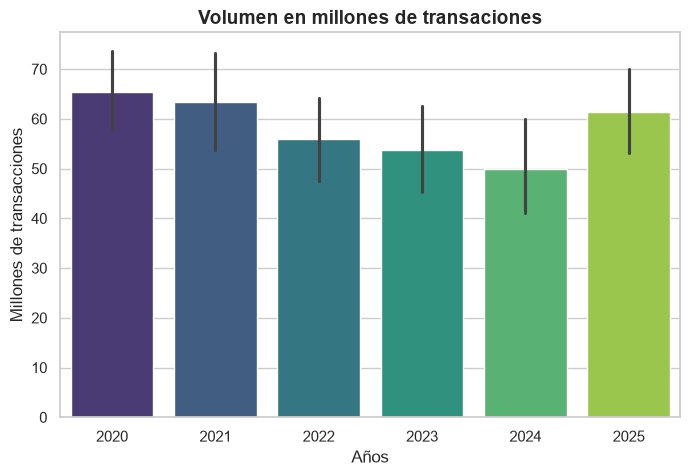

In [24]:
# 2. Generar un gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x="Año", y="Volumen_M", data=df, palette="viridis")
plt.title("Volumen en millones de transaciones", fontsize=14, fontweight="bold")
plt.xlabel("Años", fontsize=12)
plt.ylabel("Millones de transacciones", fontsize=12)
plt.show()

In [26]:
# Crear el Histograma interactivo
fig_hist = px.histogram(
    df, 
    x="Volumen_M", 
    color="Tendencia",
    nbins=15,
    title="Distribución del Volumen de Transacciones (AMZN)",
    labels={"Volumen_M": "Volumen (Millones)", "count": "Frecuencia"},
    template="plotly_white",
    barmode="overlay" # Superpone las barras de tendencia de manera elegante
)

# Mejorar el diseño estético
fig_hist.update_layout(
    title_font_size=18,
    xaxis_title="Volumen de Transacciones (M)",
    yaxis_title="Cantidad de Registros"
)

# Mostrar el gráfico en el notebook
fig_hist.show()

In [27]:
# Crear la Gráfica de Dispersión
fig_scatter = px.scatter(
    df, 
    x="Apertura", 
    y="Cierre", 
    color="Tendencia",
    size="Volumen_M",
    hover_data=["Fecha", "Trimestre"],
    title="Relación entre Precio de Apertura y Cierre",
    labels={"Apertura": "Precio de Apertura ($)", "Cierre": "Precio de Cierre ($)"},
    template="plotly_white"
)

# Ajustar detalles estéticos
fig_scatter.update_layout(
    title_font_size=18,
    xaxis_title="Precio de Apertura ($)",
    yaxis_title="Precio de Cierre ($)"
)

# Mostrar el gráfico en el notebook
fig_scatter.show()